# Linked-Read (NAIBR)
Here, we aggregate the visualizations of all size classes and depth treatments for linked-read simulations.

In [1]:
library(dplyr)
library(ggplot2)
library(ggpubr)
library(tidyr)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




Let's read in the data from the outcomes of the individual size-class assessments and combine them into a single table. Since we'll be comparing this to the long-read data, we should also add a column specifing this is linked-read data and write the entire thing into one file.

In [2]:
lr_inversions <- rbind(
    read.csv("small.sv.naibr.assessment", header = T),
    read.csv("medium.sv.naibr.assessment", header = T),
    read.csv("large.sv.naibr.assessment", header = T),
    read.csv("xl.sv.naibr.assessment", header = T)
)
lr_inversions$technology <- "linkedread"
lr_inversions$method <- "naibr"
if(!file.exists("linkedread.sv.assessment")){
    write.csv(lr_inversions, file = "linkedread.sv.assessment", row.names = F, quote = F)
}
head(lr_inversions)

,contig,inversion,id,depth,sample,size,simulated,zygosity,position_start,position_end,assessment,technology,method
,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
1,2L,1,1,0.5,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,naibr
2,2L,1,1,2.0,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,naibr
3,2L,1,1,5.0,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,naibr
4,2L,1,1,10.0,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,naibr
5,2L,1,1,20.0,1,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,naibr
6,2L,1,1,0.5,2,small,TRUE,homozygous,3193196,3214221,false negative,linkedread,naibr


In [12]:
false_positives <- Reduce(
    rbind,
    Map(
        function(x){ read.table(x, header = T)},
        list.files(pattern = "false_positives*",full.names = T)
    )
)
false_positives$assessment <- "false positive"
head(false_positives)

,position_end,sample,contig,position_start,size,depth,method,assessment
,<int>,<int>,<chr>,<int>,<chr>,<int>,<chr>,<chr>
1,26510571,11,2L,6636043,medium,5,naibr,false positive
2,6887630,11,2L,6636005,medium,5,naibr,false positive
3,8403019,11,2L,6636028,medium,5,naibr,false positive
4,21809650,11,2L,6636019,medium,10,naibr,false positive
5,6887583,11,2L,6636016,medium,10,naibr,false positive
6,29881990,11,2L,6636107,medium,10,naibr,false positive


## Summary statistics
We need to know things like:

**Per Sample-Size-Depth**
- average number of identified inversions
- average number of false positives
- recall
- precision
- $F_{1}$ score

The assessment and FP table aren't in the same format, so it would be easier to trim down the bigger table and append the false positive one to it, then do the summary stats.

In [4]:
.inversions <- select(lr_inversions, contig, position_start, position_end, sample, depth, size, assessment, method)
.inversions$datatype <- ifelse(.inversions$sample == 11, "pooled", "single-sample")
head(.inversions)

,contig,position_start,position_end,sample,depth,size,assessment,method,datatype
,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,2L,3193196,3214221,1,0.5,small,false negative,naibr,single-sample
2,2L,3193196,3214221,1,2.0,small,false negative,naibr,single-sample
3,2L,3193196,3214221,1,5.0,small,false negative,naibr,single-sample
4,2L,3193196,3214221,1,10.0,small,false negative,naibr,single-sample
5,2L,3193196,3214221,1,20.0,small,false negative,naibr,single-sample
6,2L,3193196,3214221,2,0.5,small,false negative,naibr,single-sample


It may be worth collapsing these into averages across size-depth treatments (averaging across samples)

In [5]:
metrics <- group_by(.inversions, size, depth, datatype) %>%
    summarize(
        TP = sum(assessment == "true positive"),
        FP = sum(assessment == "false positive"),
        TN = sum(assessment == "true negative"),
        FN = sum(assessment == "false negative")
    ) %>% ungroup()
metrics$precision <- metrics$TP / (metrics$TP + metrics$FP)
metrics$recall <- metrics$TP / (metrics$TP + metrics$FN)
metrics$F1 <- 2 * ((metrics$precision * metrics$recall) / (metrics$precision + metrics$recall))
metrics$depth <- metrics$depth
metrics$size <- factor(metrics$size, ordered = T, levels = c("small", "medium", "large", "xl"))
head(metrics)

`summarise()` has grouped output by 'size', 'depth'. You can override using the
`.groups` argument.


size,depth,datatype,TP,FP,TN,FN,precision,recall,F1
<ord>,<dbl>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
large,0.5,pooled,6,0,0,2,1,0.7500000,0.8571429
large,0.5,single-sample,8,0,21,51,1,0.1355932,0.2388060
large,2.0,pooled,7,0,0,1,1,0.8750000,0.9333333
large,2.0,single-sample,37,0,21,22,1,0.6271186,0.7708333
large,5.0,pooled,8,0,0,0,1,1.0000000,1.0000000
large,5.0,single-sample,50,0,21,9,1,0.8474576,0.9174312


In [6]:
greys <- c(
    "#c0c6cf",
    "#a2aab5",
    "#6e7684",
    "#54546c",
    "black"
)

colorful <- c(
    "#9b6981",
    "#682c37",
    "#f6955e" ,
    "#a8cdec"
)

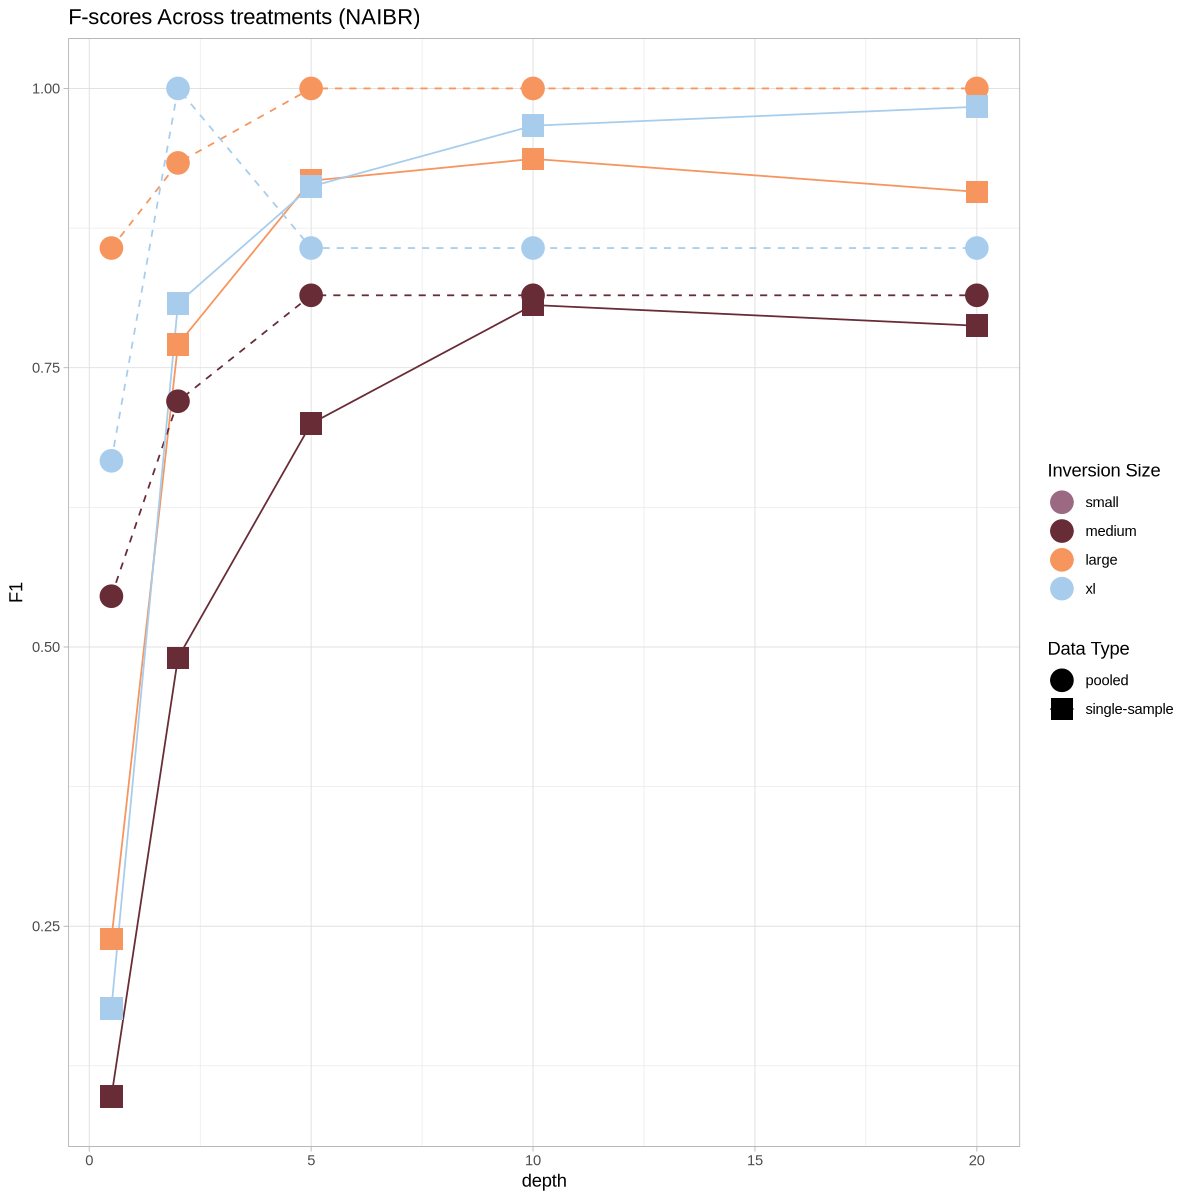

In [14]:
options(warn = -1, repr.plot.width = 10, repr.plot.height = 10)
ggplot(metrics, aes(x = depth, y = F1, color = size, shape = datatype, group = paste(size, datatype), linetype = datatype)) +
    geom_line() +
    geom_point(size = 6) +
    theme_light() +
    scale_shape_manual(name = "Data Type", values = c(19, 15)) +
    scale_color_manual(name = "Inversion Size", values = colorful) +
    scale_linetype_manual(name = "Data Type", values = c("pooled" = "dashed", "single-sample" = "solid")) +
    labs(title = "F-scores Across treatments (NAIBR)")

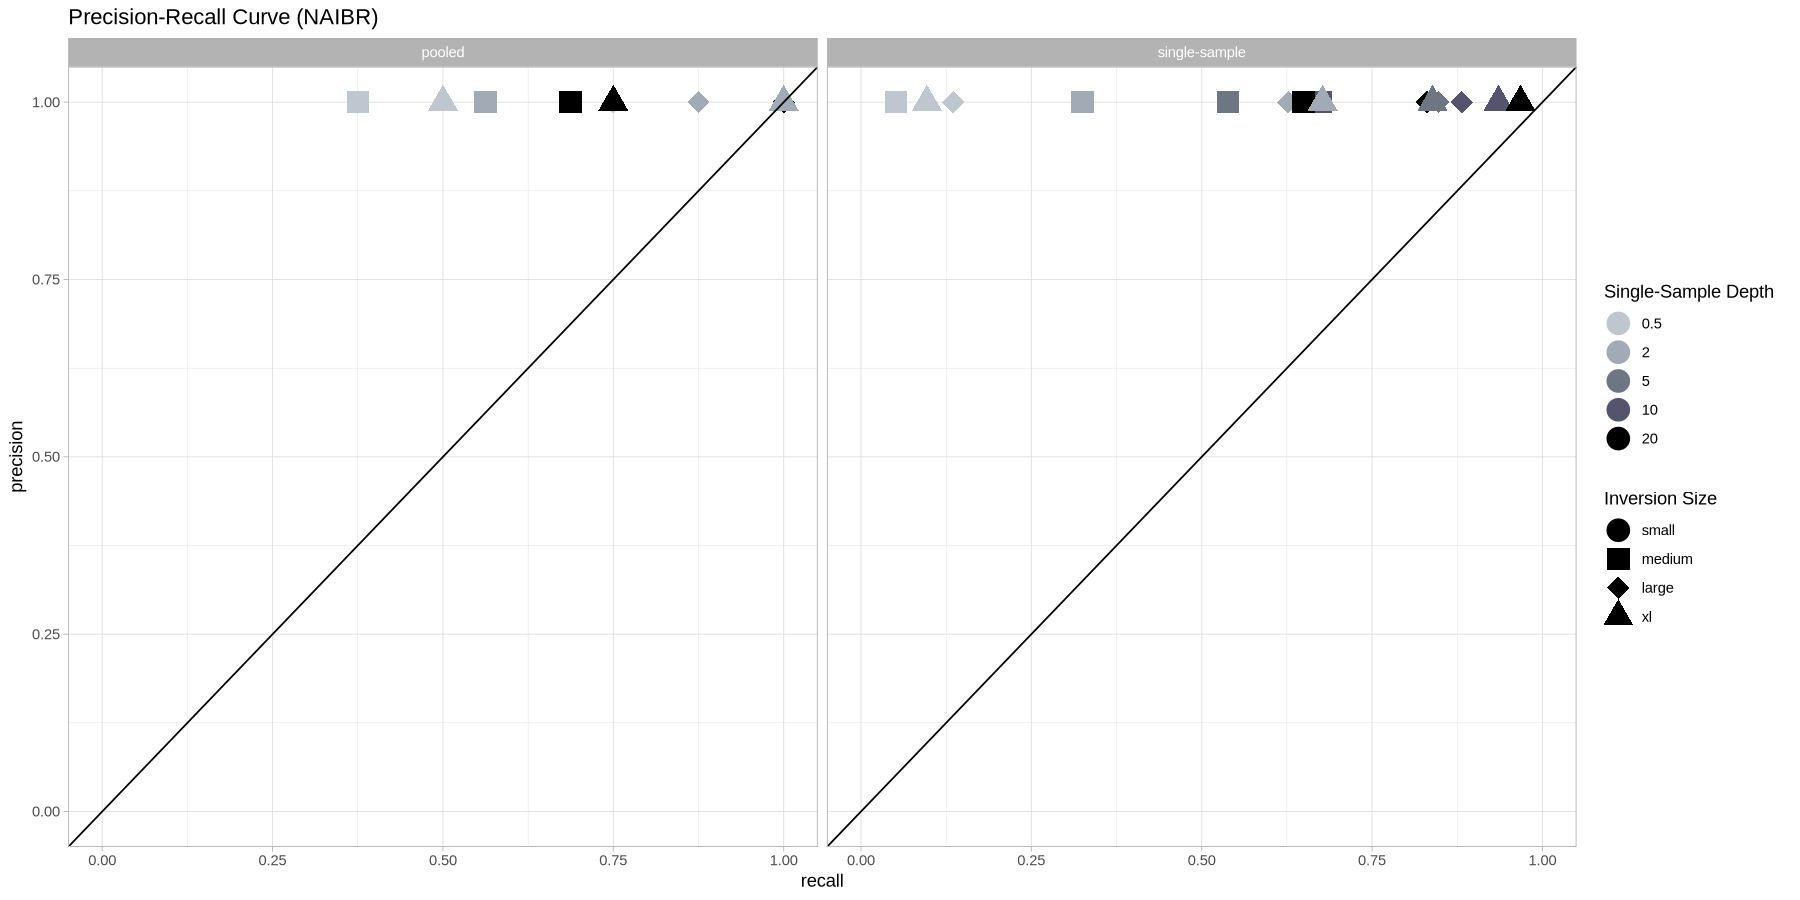

In [13]:
options(warn = -1, repr.plot.width = 15, repr.plot.height = 7.5)
ggplot(metrics, aes(x = recall, y = precision, color = as.factor(depth), shape = size)) +
    geom_point(size = 6) +
    geom_abline(intercept = 0, slope = 1) +
    theme_light() +
    scale_color_manual(name = "Single-Sample Depth", values = greys) +
    scale_shape_manual(name = "Inversion Size", values = c(19,15,18,17)) +
    coord_cartesian(xlim = c(0,1), ylim = c(0,1)) +
    labs(title = "Precision-Recall Curve (NAIBR)") +
    facet_grid(cols = vars(datatype))

### Single-Sample Detection
Let's visualize what detection looked like across all treatments with respect to false/true positive/negative. Here, we facet rows across depths and show all the size treatments across columns.

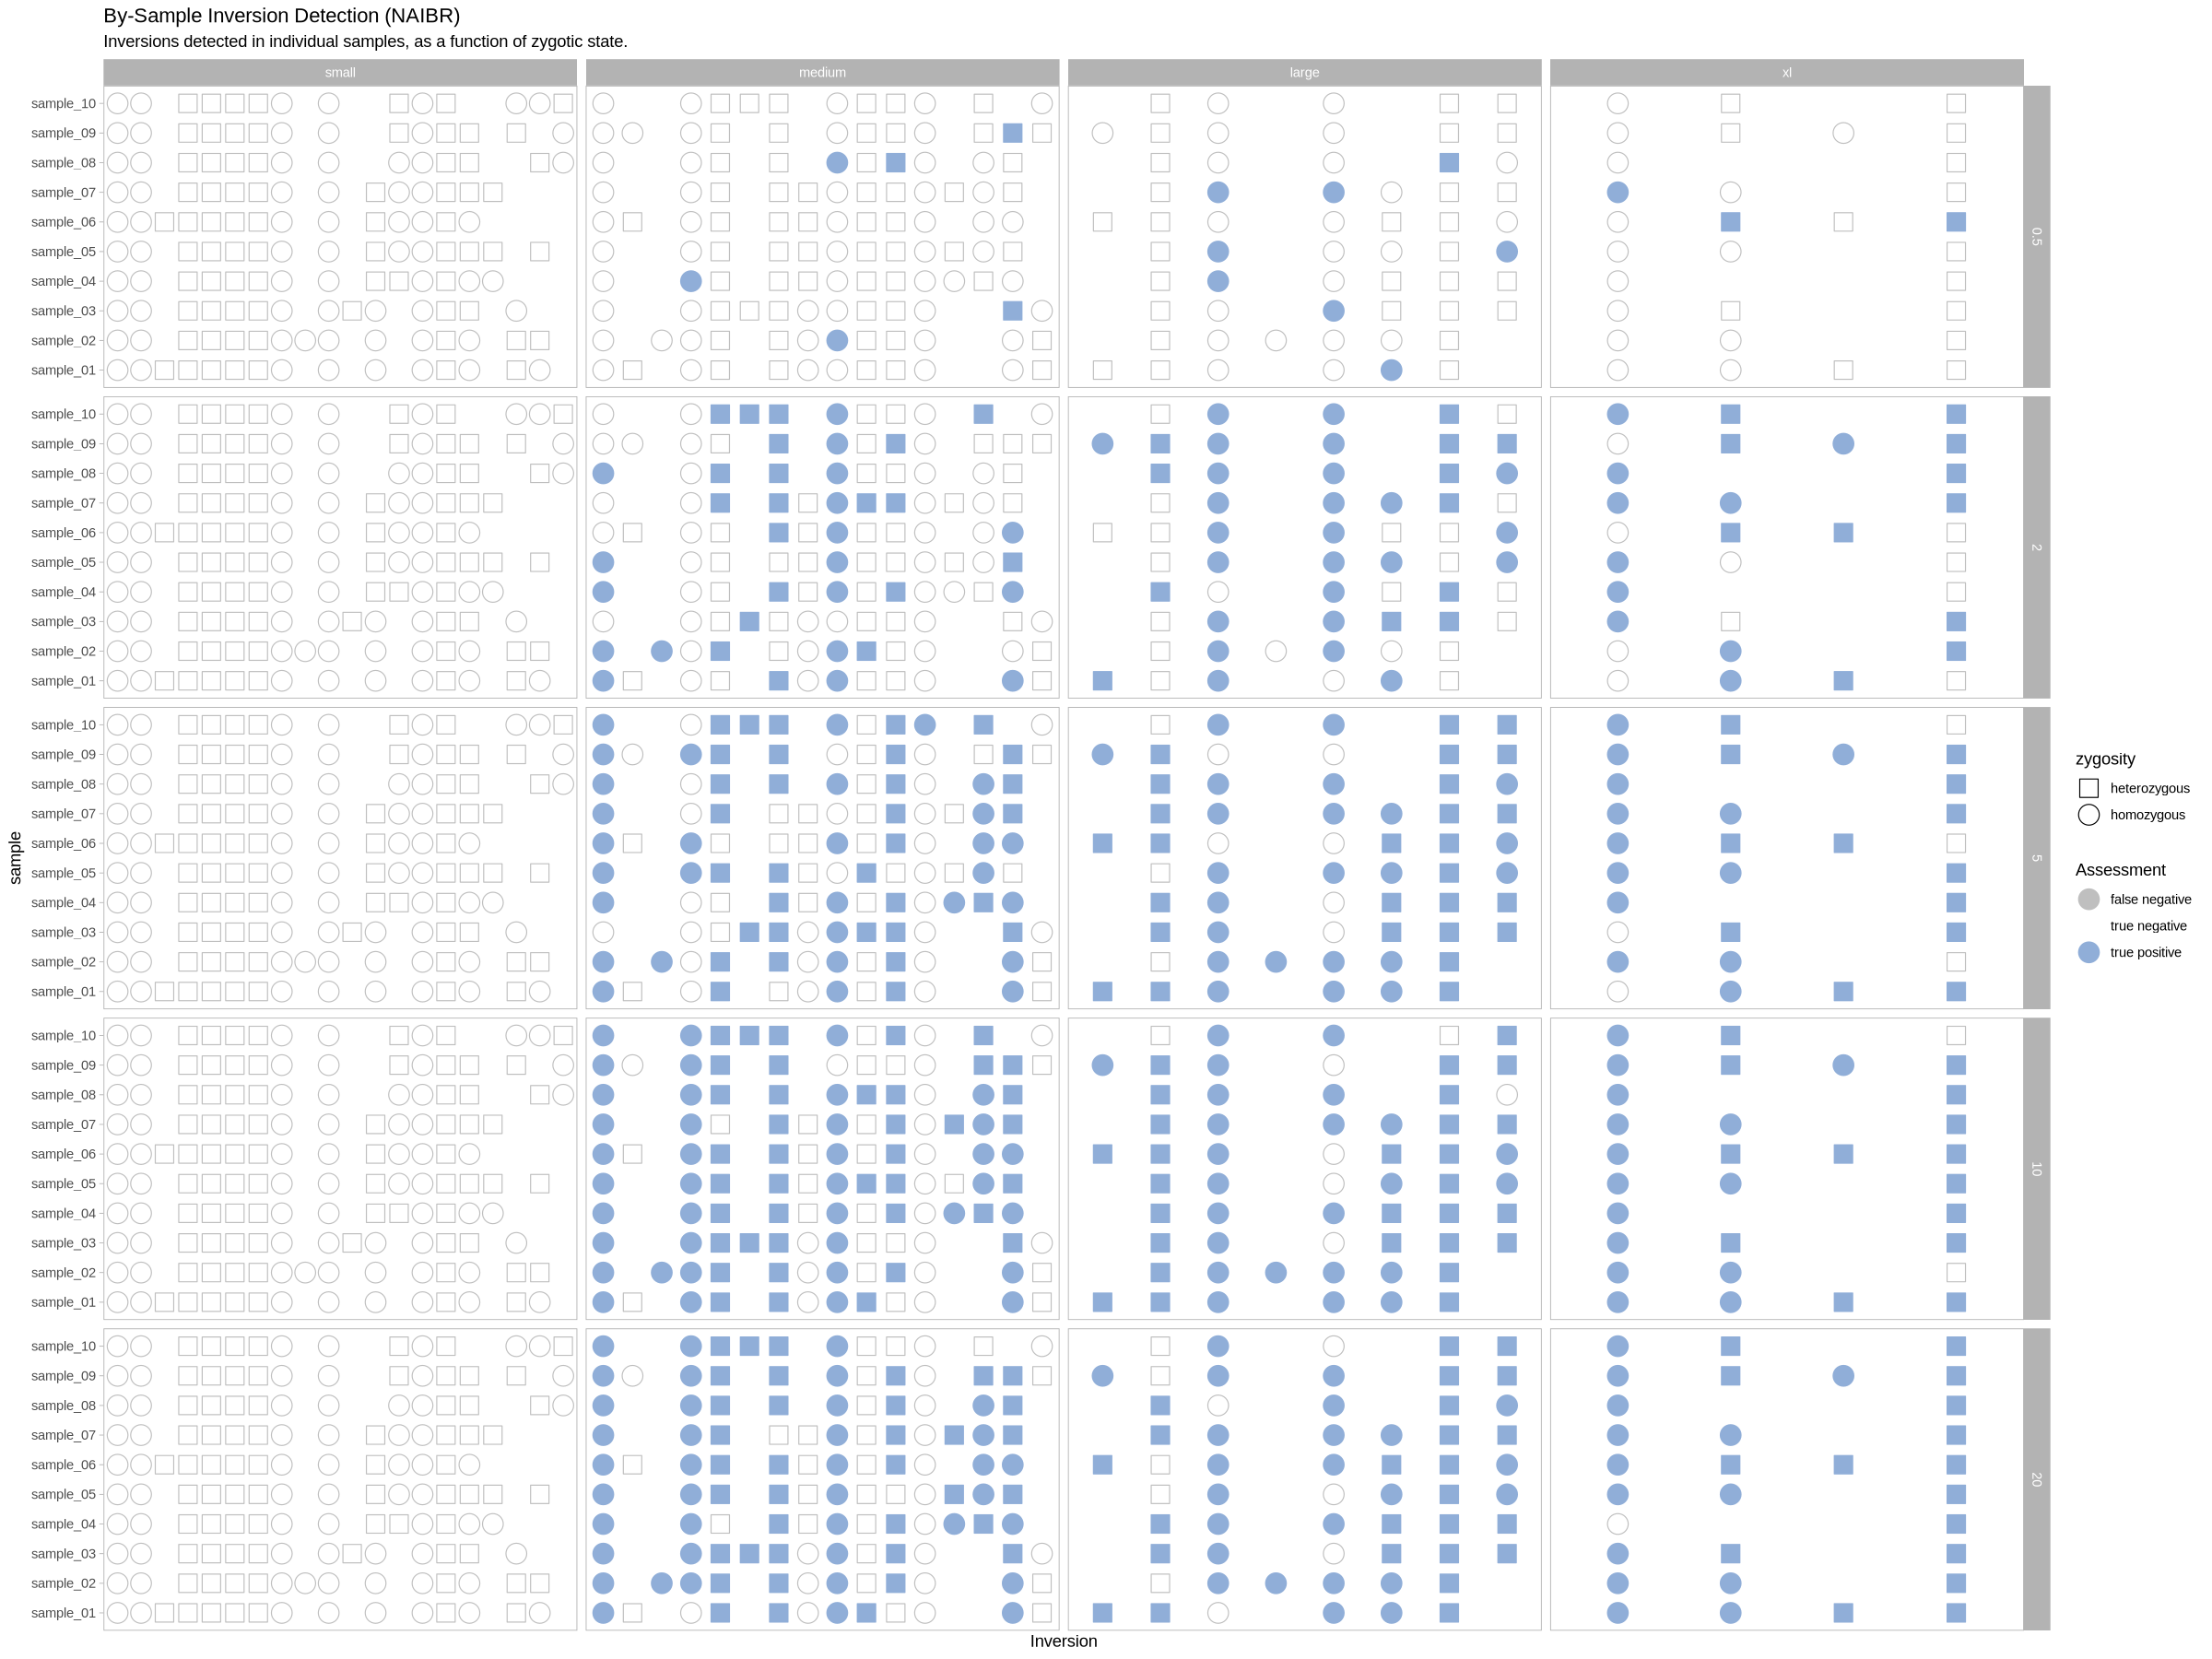

In [15]:
options(warn = -1, repr.plot.width = 20, repr.plot.height = 15)
axis_ticks <- factor(paste0("sample_", sprintf("%02d", 1:10)))
lr_inversions[lr_inversions$sample != 11,] %>%
    ggplot(aes(y = sample, x = id, color = assessment, fill = assessment, shape = zygosity)) +
        geom_point(size=6) +
        theme_light() +
        labs(title = "By-Sample Inversion Detection (NAIBR)", subtitle = "Inversions detected in individual samples, as a function of zygotic state.") +
        scale_color_manual(name = "Assessment", values = c("false negative" = "grey75", "true negative" = "white", "true positive" = "#90aed8")) +
        scale_fill_manual(name = "Assessment", values = c("false negative" = "white", "true negative" = "white", "true positive" = "#90aed8")) +
        scale_shape_manual(values = c("homozygous" = 21, "heterozygous" = 22)) +
        scale_x_discrete(name = "Inversion") +
        scale_y_discrete(limits = axis_ticks, breaks = axis_ticks) +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank()
        ) +
        facet_grid(depth ~ factor(size, levels = c("small", "medium", "large", "xl")), scales = "free_x")


### Pooled Sample Detection 

In [19]:
plot_pools_matrix <- function(data, size_treatment){
    .data <- data[data$sample == 11 & data$size == size_treatment,]
    .data$contig <- gsub("2L", "hom", .data$contig)
    .data$contig <- gsub("2R", "het", .data$contig)
    .data$contig <- gsub("3L", "rare", .data$contig)
    .data$contig <- gsub("3R", "common", .data$contig)
    .data$contig <- factor(.data$contig,levels = c("hom","het","common", "rare"), ordered = T)

    ggplot(.data, aes(y = 1, x = inversion, color = assessment, fill = assessment)) +
        geom_point(size=8, shape = 22) +
        theme_light() +
        scale_color_manual(name = "Assessment", values = c("false negative" = "grey75", "true positive" = "#90aed8")) +
        scale_fill_manual(name = "Assessment", values = c("false negative" = "white", "true negative" = "white", "true positive" = "#90aed8")) +
        scale_y_continuous(breaks = 1, name = "") +
        scale_x_discrete(name = "Inversion") +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank(),
            axis.text.y = element_blank(),
            axis.ticks.y = element_blank(),
            axis.label.y = element_blank()
        ) +
        facet_grid(cols = vars(contig), rows = vars(depth))
}

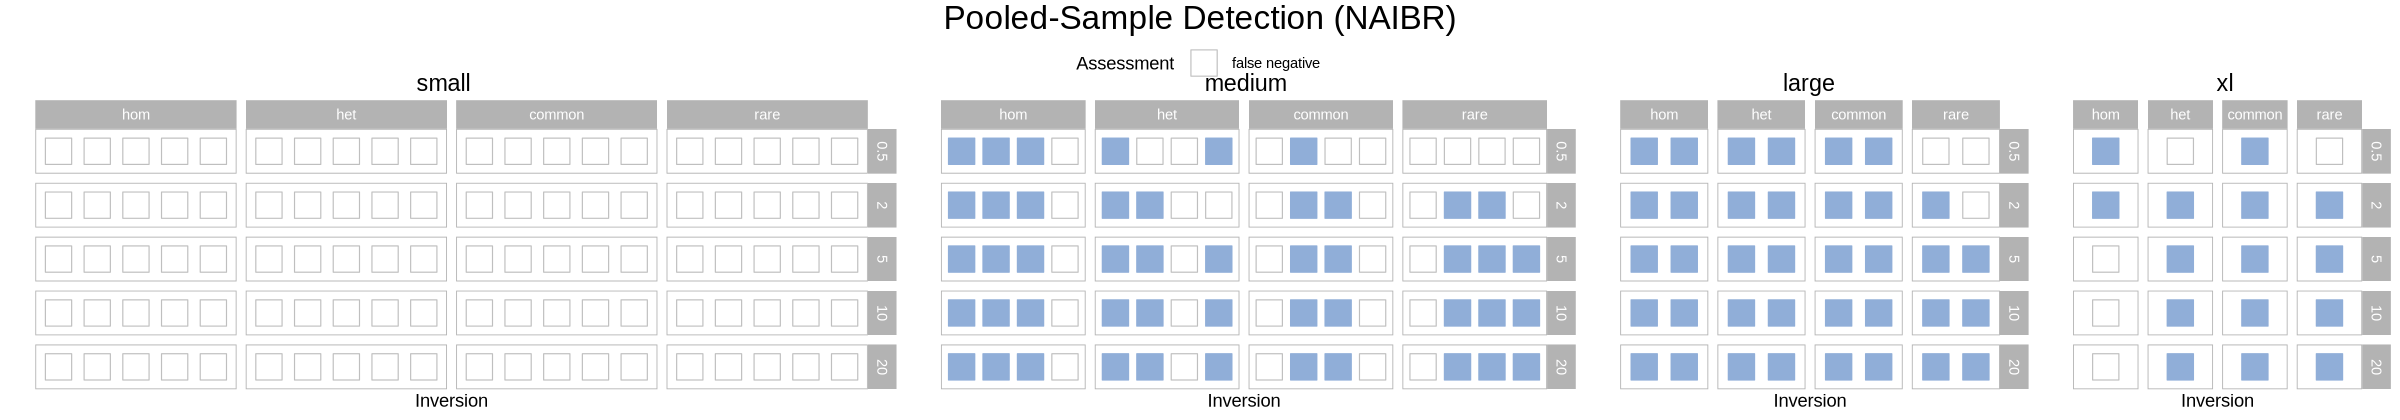

In [20]:
options(warn = -1, repr.plot.width = 20, repr.plot.height = 3.5)
plot <- ggarrange(
    plot_pools_matrix(lr_inversions, "small"),
    plot_pools_matrix(lr_inversions, "medium"),
    plot_pools_matrix(lr_inversions, "large"),
    plot_pools_matrix(lr_inversions, "xl"),
    labels = c("small", "medium", "large", "xl"),
    nrow = 1, ncol = 4, common.legend = T, font.label = c(face = "plain"), legend = "top",
    vjust = 0, label.x = c(0.43, 0.38, 0.38, 0.47),
    widths = c(1, .75, .50, .40)
)
annotate_figure(
    plot,
    top = text_grob(
        "Pooled-Sample Detection (NAIBR)", color = "black", size = 20
        )
)